# CatBoost Leakage-Safe Baseline - ExpresSo NB

Notebook นี้เป็น baseline สำหรับโจทย์ demand forecasting ร้านกาแฟ โดยยึดหลักที่คุยกันไว้:

- Target มาจาก `TRANSACTION + ORDER + PRODUCT` ตาม canonical definition
- Forecast ระดับ `store_id × category × forecast_date × horizon`
- แยกโมเดล CatBoost เป็น 3 ตัวสำหรับ `1d`, `7d`, `1m`
- Feature จากยอดขายใช้ได้ถึง `decision_day = forecast_date - horizon` เท่านั้น
- Test ใช้ train-only cutoff: ถ้า decision day อยู่ใน Nov-Dec จะ cap history ที่ `2024-10-31`
- ไม่ใช้ `test/TRANSACTION.csv`, `test/ORDER.csv`, หรือ `test/INVENTORY.csv`
- ใช้ MAE เป็น metric หลักตาม leaderboard


## 1. ติดตั้ง/โหลด Library และตั้งค่า Config

Cell นี้โหลด library ทั้งหมด ตั้ง path dataset local และกำหนด parameter หลักของ validation/model


In [ ]:
from google.colab import userdata
username = userdata.get('KAGGLE_USER')
key = userdata.get('KAGGLE_KEY')
!mkdir -p ~/.kaggle
!echo '{{"username":"{username}","key":"{key}"}}' > ~/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

#!/bin/bash
!kaggle competitions download -c super-ai-engineer-season-6-coffee-chain-hackathon
!unzip /content/super-ai-engineer-season-6-coffee-chain-hackathon.zip

100% 36.6M/36.6M [00:03<00:00, 11.9MB/s]

Archive:  /content/super-ai-engineer-season-6-coffee-chain-hackathon.zip
  inflating: sample_submission_with_id.csv  
  inflating: test/DATE_DIM.csv       
  inflating: test/LOCAL_EVENT.csv    
  inflating: test/PRODUCT.csv        
  inflating: test/PROMOTION.csv      
  inflating: test/STORE.csv          
  inflating: train/CUSTOMER.csv      
  inflating: train/DATE_DIM.csv      
  inflating: train/INVENTORY.csv     
  inflating: train/LOCAL_EVENT.csv   
  inflating: train/ORDER.csv         
  inflating: train/PRODUCT.csv       
  inflating: train/PROMOTION.csv     
  inflating: train/STORE.csv         
  inflating: train/TRANSACTION.csv   


In [ ]:
from __future__ import annotations

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

try:
    from catboost import CatBoostRegressor, Pool
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])
    from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

DATA_DIR_CANDIDATES = [
    Path(os.environ["COFFEE_DATA_DIR"]) if "COFFEE_DATA_DIR" in os.environ else None,
    Path(r"C:\Users\ASUS\Downloads\super-ai-engineer-season-6-coffee-chain-hackathon"),
    Path(r"C:\Users\Natth\Downloads\super-ai-engineer-season-6-coffee-chain-hackathon"),
    Path("/content/super-ai-engineer-season-6-coffee-chain-hackathon"),
    Path("/content/kaggle_competition"),
    Path("/content"),
]
DATA_DIR_CANDIDATES = [p for p in DATA_DIR_CANDIDATES if p is not None]
DATA_DIR = next(
    (p for p in DATA_DIR_CANDIDATES if (p / "train").exists() and (p / "test").exists()),
    DATA_DIR_CANDIDATES[0],
)
OUTPUT_PATH = Path("submission_catboost_high_corr.csv")

TRAIN_START = pd.Timestamp("2023-01-01")
TRAIN_END = pd.Timestamp("2024-10-31")
VALID_START = pd.Timestamp("2024-09-01")

HORIZON_TO_DAYS = {"1d": 1, "7d": 7, "1m": 30}
USE_STOCKOUT_WEIGHTS = True
STOCKOUT_WEIGHT = 0.30
SEED = 42

MODEL_PARAMS = {
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "iterations": 2500,
    "learning_rate": 0.045,
    "depth": 6,
    "l2_leaf_reg": 8,
    "random_seed": SEED,
    "od_type": "Iter",
    "od_wait": 150,
    "verbose": 200,
    "allow_writing_files": False,
    "thread_count": -1,
}

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_PATH:", OUTPUT_PATH.resolve())


DATA_DIR: /content
OUTPUT_PATH: /content/submission_catboost_high_corr.csv


## 2. ตรวจโครงสร้างไฟล์

Cell นี้เช็กว่า path ที่ตั้งไว้มี `train/`, `test/`, และไฟล์ submission จริงหรือไม่


In [ ]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

print("Root files/folders:")
for p in sorted(DATA_DIR.iterdir()):
    print(" -", p.name)

print("\nTrain files:")
for p in sorted((DATA_DIR / "train").glob("*.csv")):
    print(" -", p.name)

print("\nTest files:")
for p in sorted((DATA_DIR / "test").glob("*.csv")):
    print(" -", p.name)


Root files/folders:
 - .config
 - sample_data
 - sample_submission_with_id.csv
 - super-ai-engineer-season-6-coffee-chain-hackathon.zip
 - test
 - train

Train files:
 - CUSTOMER.csv
 - DATE_DIM.csv
 - INVENTORY.csv
 - LOCAL_EVENT.csv
 - ORDER.csv
 - PRODUCT.csv
 - PROMOTION.csv
 - STORE.csv
 - TRANSACTION.csv

Test files:
 - DATE_DIM.csv
 - LOCAL_EVENT.csv
 - PRODUCT.csv
 - PROMOTION.csv
 - STORE.csv


## 3. Helper Functions

Cell นี้รวมฟังก์ชันเล็ก ๆ สำหรับอ่านไฟล์, normalize column, และหา sample submission


In [ ]:
def read_csv(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df


def find_sample_submission(data_dir: Path) -> Path:
    candidates = [
        data_dir / "sample_submission.csv",
        data_dir / "sample_submission_with_id.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("sample_submission.csv / sample_submission_with_id.csv not found")


## 4. Load Train/Test Tables

Cell นี้โหลดทุกตารางที่จำเป็น โดย test จะโหลดเฉพาะ lookup ที่กติกาอนุญาต


In [ ]:
train_dir = DATA_DIR / "train"
test_dir = DATA_DIR / "test"

txn = normalize_columns(read_csv(train_dir / "TRANSACTION.csv"))
order = normalize_columns(read_csv(train_dir / "ORDER.csv"))
inventory = normalize_columns(read_csv(train_dir / "INVENTORY.csv"))
promo_train = normalize_columns(read_csv(train_dir / "PROMOTION.csv"))
event_train = normalize_columns(read_csv(train_dir / "LOCAL_EVENT.csv"))
date_train = normalize_columns(read_csv(train_dir / "DATE_DIM.csv"))
store_train = normalize_columns(read_csv(train_dir / "STORE.csv"))
product_train = normalize_columns(read_csv(train_dir / "PRODUCT.csv"))

promo_test = normalize_columns(read_csv(test_dir / "PROMOTION.csv"))
event_test = normalize_columns(read_csv(test_dir / "LOCAL_EVENT.csv"))
date_test = normalize_columns(read_csv(test_dir / "DATE_DIM.csv"))
store_test = normalize_columns(read_csv(test_dir / "STORE.csv"))
product_test = normalize_columns(read_csv(test_dir / "PRODUCT.csv"))

sample = read_csv(find_sample_submission(DATA_DIR))

tables = {
    "TRANSACTION": txn,
    "ORDER": order,
    "INVENTORY": inventory,
    "PROMOTION train": promo_train,
    "LOCAL_EVENT train": event_train,
    "DATE_DIM train": date_train,
    "STORE train": store_train,
    "PRODUCT train": product_train,
    "sample": sample,
}

for name, df in tables.items():
    print(f"{name:18s}", df.shape)


TRANSACTION        (2858050, 6)
ORDER              (1376133, 7)
INVENTORY          (804000, 9)
PROMOTION train    (31314, 10)
LOCAL_EVENT train  (1440, 5)
DATE_DIM train     (731, 12)
STORE train        (20, 8)
PRODUCT train      (60, 7)
sample             (25620, 2)


## 5. EDA: Schema, Missingness, Cardinality

Cell นี้ดู dtype, missing values, และจำนวน unique ของแต่ละ column เพื่อจับปัญหาข้อมูลก่อนทำ feature


In [ ]:
def missing_report(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing": [df[c].isna().sum() for c in df.columns],
        "missing_pct": [100 * df[c].isna().mean() for c in df.columns],
        "nunique": [df[c].nunique(dropna=True) for c in df.columns],
    })

schema_report = pd.concat(
    [
        missing_report(txn, "TRANSACTION"),
        missing_report(order, "ORDER"),
        missing_report(inventory, "INVENTORY"),
        missing_report(promo_train, "PROMOTION"),
        missing_report(event_train, "LOCAL_EVENT"),
        missing_report(date_train, "DATE_DIM"),
        missing_report(store_train, "STORE"),
        missing_report(product_train, "PRODUCT"),
    ],
    ignore_index=True,
).sort_values(["missing_pct", "table", "column"], ascending=[False, True, True])

display(schema_report.head(40))


,table,column,dtype,missing,missing_pct,nunique
45,DATE_DIM,holiday_name,object,703,96.169631,12
10,ORDER,customer_id,float64,825292,59.971820,4353
37,DATE_DIM,date,object,0,0.000000,731
38,DATE_DIM,day_of_week,object,0,0.000000,7
44,DATE_DIM,is_holiday,bool,0,0.000000,2
47,DATE_DIM,is_payday,bool,0,0.000000,2
48,DATE_DIM,is_rainy_season,bool,0,0.000000,2
46,DATE_DIM,is_school_break,bool,0,0.000000,2
43,DATE_DIM,is_weekend,bool,0,0.000000,2
40,DATE_DIM,month,int64,0,0.000000,12


## 6. EDA: Date Range และ Category

Cell นี้ตรวจช่วงวันที่, จำนวน store, และ category ที่เป็น target ของการแข่งขัน


In [ ]:
order["date"] = pd.to_datetime(order["date"])
inventory["date"] = pd.to_datetime(inventory["date"])
date_train["date"] = pd.to_datetime(date_train["date"])
date_test["date"] = pd.to_datetime(date_test["date"])

print("Order date range:", order["date"].min(), "to", order["date"].max())
print("Inventory date range:", inventory["date"].min(), "to", inventory["date"].max())
print("Train DATE_DIM range:", date_train["date"].min(), "to", date_train["date"].max())
print("Test DATE_DIM range:", date_test["date"].min(), "to", date_test["date"].max())
print("n stores:", order["store_id"].nunique())
print("n products:", product_train["product_id"].nunique())
print("categories:", sorted(product_train["category"].dropna().astype(str).unique().tolist()))


Order date range: 2023-01-01 00:00:00 to 2024-10-31 00:00:00
Inventory date range: 2023-01-01 00:00:00 to 2024-10-31 00:00:00
Train DATE_DIM range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Test DATE_DIM range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
n stores: 20
n products: 60
categories: ['Bakery', 'Chocolate & Milk', 'Coffee', 'Juice & Smoothie', 'Merchandise', 'Savory Bakery', 'Tea']


## 7. สร้าง Canonical Target

Cell นี้สร้าง target ตามโจทย์: sum `TRANSACTION.units_sold` หลัง merge กับ `ORDER` และ `PRODUCT`


In [ ]:
def build_canonical_target(txn: pd.DataFrame, order: pd.DataFrame, product: pd.DataFrame) -> pd.DataFrame:
    required = {
        "TRANSACTION": (txn, ["order_id", "product_id", "units_sold"]),
        "ORDER": (order, ["order_id", "store_id", "date"]),
        "PRODUCT": (product, ["product_id", "category"]),
    }
    for name, (df, cols) in required.items():
        missing = [c for c in cols if c not in df.columns]
        if missing:
            raise ValueError(f"{name} missing columns: {missing}")

    target = (
        txn[["order_id", "product_id", "units_sold"]]
        .merge(order[["order_id", "store_id", "date"]], on="order_id", how="left")
        .merge(product[["product_id", "category"]], on="product_id", how="left")
        .groupby(["store_id", "category", "date"], as_index=False)["units_sold"]
        .sum()
    )
    target["store_id"] = target["store_id"].astype(int)
    target["category"] = target["category"].astype(str)
    target["date"] = pd.to_datetime(target["date"])
    target["units_sold"] = target["units_sold"].astype("float32")
    return target


target = build_canonical_target(txn, order, product_train)
print(target.shape)
display(target.head())


(92340, 4)


,store_id,category,date,units_sold
0,1,Bakery,2023-01-01,18.0
1,1,Bakery,2023-01-02,33.0
2,1,Bakery,2023-01-03,21.0
3,1,Bakery,2023-01-04,28.0
4,1,Bakery,2023-01-05,39.0


## 8. EDA: Target Distribution

Cell นี้ดูยอดขายรวมตาม category/store และ pattern รายวัน เพื่อเข้าใจข้อมูลก่อน train


,sum,mean,median,std,max,count
category,,,,,,
Coffee,1942678.0,146.705780,127.0,88.863983,1607.0,13242
Tea,609945.0,46.061394,39.0,31.816366,589.0,13242
Bakery,476108.0,35.954388,31.0,23.161654,398.0,13242
Savory Bakery,376799.0,28.459139,24.0,18.712248,291.0,13240
Chocolate & Milk,277784.0,20.996523,18.0,15.106545,313.0,13230
Juice & Smoothie,167674.0,12.741185,11.0,9.545259,159.0,13160
Merchandise,98361.0,7.575554,6.0,5.521930,95.0,12984


,sum,mean,median,std,max,count
store_id,,,,,,
6,360102.0,76.780807,44.0,97.504936,1607.0,4690
10,314417.0,67.054169,39.0,81.984322,1240.0,4689
9,287727.0,61.362125,36.0,76.527855,1094.0,4689
5,272670.0,58.163395,34.0,72.066513,840.0,4688
15,266427.0,56.855953,33.0,70.696838,1446.0,4686
2,238430.0,50.848797,29.0,64.494675,962.0,4689
14,223404.0,47.705318,28.0,58.773857,650.0,4683
8,210335.0,44.857113,26.0,53.427731,517.0,4689
3,207199.0,44.226040,26.0,52.870094,554.0,4685


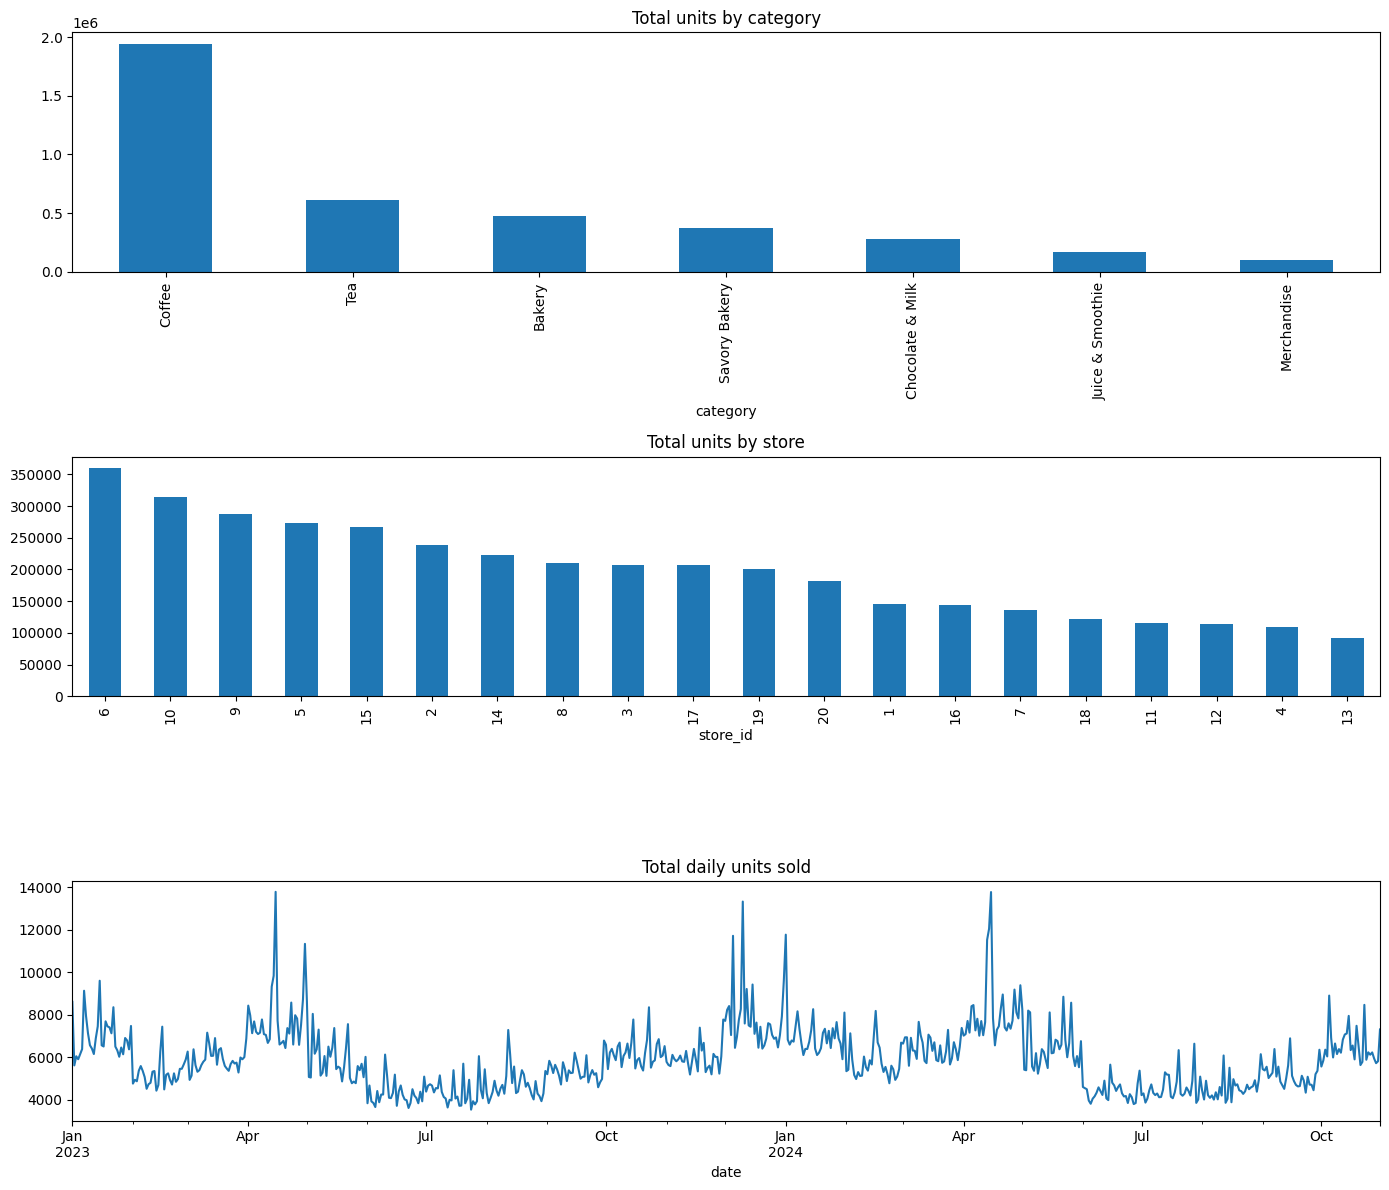

In [ ]:
cat_summary = (
    target.groupby("category")["units_sold"]
    .agg(["sum", "mean", "median", "std", "max", "count"])
    .sort_values("sum", ascending=False)
)
store_summary = (
    target.groupby("store_id")["units_sold"]
    .agg(["sum", "mean", "median", "std", "max", "count"])
    .sort_values("sum", ascending=False)
)
daily_total = target.groupby("date")["units_sold"].sum()

display(cat_summary)
display(store_summary)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
cat_summary["sum"].plot(kind="bar", ax=axes[0], title="Total units by category")
store_summary["sum"].plot(kind="bar", ax=axes[1], title="Total units by store")
daily_total.plot(ax=axes[2], title="Total daily units sold")
plt.tight_layout()
plt.show()


## 9. สร้าง Full Grid และเติม Zero-Sales Days

Cell นี้ทำให้ข้อมูลครบทุก `store × category × date` แล้วเติมวันไม่มียอดขายเป็น 0 ตามโจทย์


In [ ]:
def make_full_grid(target: pd.DataFrame) -> tuple[pd.DataFrame, list[int], list[str]]:
    stores = sorted(target["store_id"].dropna().astype(int).unique().tolist())
    categories = sorted(target["category"].dropna().astype(str).unique().tolist())
    dates = pd.date_range(TRAIN_START, TRAIN_END, freq="D")
    grid = pd.MultiIndex.from_product(
        [stores, categories, dates],
        names=["store_id", "category", "date"],
    ).to_frame(index=False)
    full = grid.merge(target, on=["store_id", "category", "date"], how="left")
    full["units_sold"] = full["units_sold"].fillna(0).astype("float32")
    full = full.sort_values(["store_id", "category", "date"]).reset_index(drop=True)
    return full, stores, categories


full, stores, categories = make_full_grid(target)
print("Full grid:", full.shape)
print("Expected:", len(stores) * len(categories) * len(pd.date_range(TRAIN_START, TRAIN_END)))
display(full.head())


Full grid: (93800, 4)
Expected: 93800


,store_id,category,date,units_sold
0,1,Bakery,2023-01-01,18.0
1,1,Bakery,2023-01-02,33.0
2,1,Bakery,2023-01-03,21.0
3,1,Bakery,2023-01-04,28.0
4,1,Bakery,2023-01-05,39.0


## 10. EDA: Sparsity / Zero Rate

Cell นี้ดูว่าแต่ละ `store × category` มีวันยอดขายเป็น 0 เยอะแค่ไหน ซึ่งช่วยอธิบาย intermittent demand


,store_id,category,zero_rate
109,16,Merchandise,0.243284
108,16,Juice & Smoothie,0.240299
107,16,Coffee,0.235821
106,16,Chocolate & Milk,0.235821
105,16,Bakery,0.235821
111,16,Tea,0.235821
110,16,Savory Bakery,0.235821
88,13,Merchandise,0.089552
81,12,Merchandise,0.058209
123,18,Merchandise,0.052239


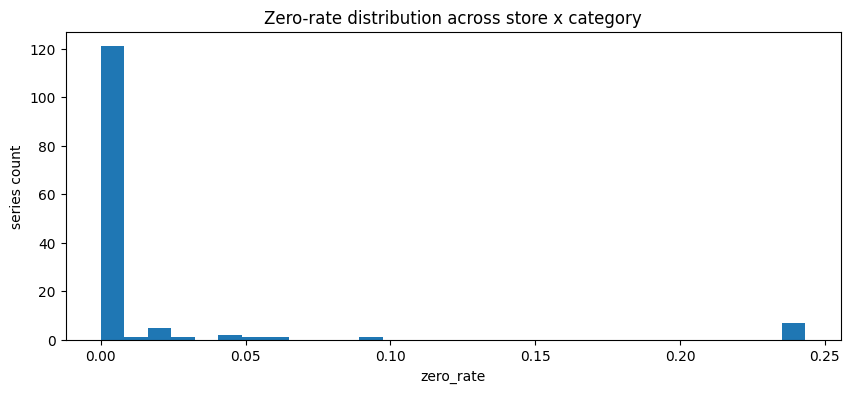

In [ ]:
zero_rate = (
    full.groupby(["store_id", "category"])["units_sold"]
    .apply(lambda s: (s == 0).mean())
    .rename("zero_rate")
    .reset_index()
    .sort_values("zero_rate", ascending=False)
)

display(zero_rate.head(20))
plt.figure(figsize=(10, 4))
plt.hist(zero_rate["zero_rate"], bins=30)
plt.title("Zero-rate distribution across store x category")
plt.xlabel("zero_rate")
plt.ylabel("series count")
plt.show()


## 11. สร้าง Stockout Target Weight

Cell นี้ aggregate `INVENTORY.is_stockout` เป็นระดับ `store × category × date` สำหรับ down-weight train rows ที่ยอดขายอาจถูก truncate  
สำคัญ: เราไม่ uncensor demand และไม่ใช้ `INVENTORY.units_sold` เป็น target


In [ ]:
def build_stockout_by_category(inventory: pd.DataFrame, product: pd.DataFrame) -> pd.DataFrame:
    inv = inventory.copy()
    inv["date"] = pd.to_datetime(inv["date"])
    inv = inv.merge(product[["product_id", "category"]], on="product_id", how="left")
    out = (
        inv.groupby(["store_id", "category", "date"], as_index=False)
        .agg(
            stockout_flag=("is_stockout", "max"),
            stockout_rate=("is_stockout", "mean"),
            closing_stock_sum=("closing_stock", "sum"),
        )
    )
    out["category"] = out["category"].astype(str)
    return out


stockout_cat = build_stockout_by_category(inventory, product_train)
full = full.merge(stockout_cat, on=["store_id", "category", "date"], how="left")
for c in ["stockout_flag", "stockout_rate", "closing_stock_sum"]:
    full[c] = full[c].fillna(0).astype("float32")

print("Stockout category rows:", stockout_cat.shape)
print("Mean stockout flag:", full["stockout_flag"].mean())
display(stockout_cat.head())


Stockout category rows: (93800, 6)
Mean stockout flag: 0.34615138


,store_id,category,date,stockout_flag,stockout_rate,closing_stock_sum
0,1,Bakery,2023-01-01,True,0.142857,38
1,1,Bakery,2023-01-02,True,0.142857,34
2,1,Bakery,2023-01-03,True,0.142857,50
3,1,Bakery,2023-01-04,True,0.142857,35
4,1,Bakery,2023-01-05,True,0.142857,28


## 12. สร้าง Anchor Features จากข้อมูลอดีต

Cell นี้สร้าง lag/rolling feature ที่ anchor date  
สำหรับ training: `anchor_date = forecast_date - h`  
สำหรับ test: `anchor_date = min(decision_date, 2024-10-31)`


In [ ]:

def rolling_group(series: pd.Series, keys, window: int, fn: str, min_periods: int = 1) -> pd.Series:
    grouped = series.groupby(keys, sort=False)
    if fn == "mean":
        return grouped.transform(lambda s: s.rolling(window, min_periods=min_periods).mean())
    if fn == "std":
        return grouped.transform(lambda s: s.rolling(window, min_periods=min_periods).std())
    if fn == "max":
        return grouped.transform(lambda s: s.rolling(window, min_periods=min_periods).max())
    if fn == "min":
        return grouped.transform(lambda s: s.rolling(window, min_periods=min_periods).min())
    if fn == "nonzero_rate":
        return grouped.transform(lambda s: (s > 0).astype("float32").rolling(window, min_periods=min_periods).mean())
    raise ValueError(fn)


def make_anchor_features(full: pd.DataFrame) -> pd.DataFrame:
    """Build sales/inventory features as of anchor_date.

    In the training/test frames, anchor_date is the decision day, capped at
    2024-10-31 for test rows. Therefore sales_lag0 and all rolling windows here
    only use information observable on or before the decision day.
    """
    df = full.sort_values(["store_id", "category", "date"]).copy()
    group_keys = [df["store_id"], df["category"]]
    sales_g = df.groupby(["store_id", "category"], sort=False)["units_sold"]

    out = df[["store_id", "category", "date"]].rename(columns={"date": "anchor_date"}).copy()

    # Strong lag-correlation features. sales_lag0 is the latest sales observed on
    # the decision day, not the forecast date, so it is leakage-safe after merge.
    out["sales_lag0"] = df["units_sold"].astype("float32")
    for lag in [7, 14, 21, 28, 35, 56, 84]:
        out[f"sales_lag{lag}"] = sales_g.shift(lag).astype("float32")

    # High-correlation rolling windows from EDA: 7/14/28/56, with 21d added as
    # the middle weekly window requested for comparison.
    for w in [7, 14, 21, 28, 56]:
        min_p = max(2, w // 2)
        out[f"sales_roll_mean_{w}"] = rolling_group(df["units_sold"], group_keys, w, "mean", min_periods=min_p).astype("float32")
        out[f"sales_roll_nonzero_{w}"] = rolling_group(df["units_sold"], group_keys, w, "nonzero_rate", min_periods=min_p).astype("float32")

    for w in [28, 56]:
        min_p = max(2, w // 2)
        out[f"sales_roll_std_{w}"] = rolling_group(df["units_sold"], group_keys, w, "std", min_periods=min_p).fillna(0).astype("float32")
        out[f"sales_roll_max_{w}"] = rolling_group(df["units_sold"], group_keys, w, "max", min_periods=min_p).astype("float32")

    out["sales_trend_7_vs_28"] = ((out["sales_roll_mean_7"] / (out["sales_roll_mean_28"].abs() + 1.0)) - 1.0).astype("float32")
    out["sales_cv_28"] = (out["sales_roll_std_28"] / (out["sales_roll_mean_28"].abs() + 1.0)).astype("float32")

    # Inventory/stockout history. These are also anchored at the decision day.
    out["stockout_lag0"] = df["stockout_flag"].astype("float32")
    out["stockout_rate_roll_28"] = rolling_group(df["stockout_flag"], group_keys, 28, "mean", min_periods=7).astype("float32")
    out["closing_stock_roll_mean_28"] = rolling_group(df["closing_stock_sum"], group_keys, 28, "mean", min_periods=7).astype("float32")

    return out


anchor_features = make_anchor_features(full)
print(anchor_features.shape)
display(anchor_features.head())


(93800, 30)


,store_id,category,anchor_date,sales_lag0,sales_lag7,sales_lag14,sales_lag21,sales_lag28,sales_lag35,sales_lag56,sales_lag84,sales_roll_mean_7,sales_roll_nonzero_7,sales_roll_mean_14,sales_roll_nonzero_14,sales_roll_mean_21,sales_roll_nonzero_21,sales_roll_mean_28,sales_roll_nonzero_28,sales_roll_mean_56,sales_roll_nonzero_56,sales_roll_std_28,sales_roll_max_28,sales_roll_std_56,sales_roll_max_56,sales_trend_7_vs_28,sales_cv_28,stockout_lag0,stockout_rate_roll_28,closing_stock_roll_mean_28
0,1,Bakery,2023-01-01,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN
1,1,Bakery,2023-01-02,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN
2,1,Bakery,2023-01-03,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN
3,1,Bakery,2023-01-04,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN
4,1,Bakery,2023-01-05,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.799999,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN


## 13. เตรียม DATE_DIM Features

Cell นี้รวม calendar lookup จาก train/test เพราะเป็นข้อมูลที่รู้ล่วงหน้าและกติกาอนุญาต


In [ ]:

def prepare_date_features(date_train: pd.DataFrame, date_test: pd.DataFrame) -> pd.DataFrame:
    date_all = pd.concat([date_train, date_test], ignore_index=True).drop_duplicates("date")
    date_all["date"] = pd.to_datetime(date_all["date"])

    # Known-future calendar features are allowed by the rules.
    date_all["day_of_week"] = date_all["date"].dt.day_name()
    date_all["day_of_week_num"] = date_all["date"].dt.dayofweek.astype("int16")
    date_all["day_of_month"] = date_all["date"].dt.day.astype("int16")
    date_all["month"] = date_all["date"].dt.month.astype("int16")
    date_all["quarter"] = date_all["date"].dt.quarter.astype("int16")
    date_all["week_number"] = date_all["date"].dt.isocalendar().week.astype("int16")
    date_all["is_month_start"] = date_all["date"].dt.is_month_start.astype("int8")
    date_all["is_month_end"] = date_all["date"].dt.is_month_end.astype("int8")

    # Helpful for explaining April/Songkran peaks in validation/EDA.
    date_all["is_songkran_window"] = ((date_all["month"] == 4) & date_all["day_of_month"].between(10, 17)).astype("int8")

    if "holiday_name" in date_all.columns:
        date_all["holiday_name"] = date_all["holiday_name"].fillna("none").astype(str)
    else:
        date_all["holiday_name"] = "none"

    bool_cols = ["is_weekend", "is_holiday", "is_school_break", "is_payday", "is_rainy_season"]
    for c in bool_cols:
        if c in date_all.columns:
            date_all[c] = date_all[c].fillna(0).astype(int)
        else:
            date_all[c] = 0
    return date_all


date_features = prepare_date_features(date_train, date_test)
print(date_features.shape)
display(date_features.head())


(731, 17)


,date,day_of_week,week_number,month,quarter,year,is_weekend,is_holiday,holiday_name,is_school_break,is_payday,is_rainy_season,day_of_week_num,day_of_month,is_month_start,is_month_end,is_songkran_window
0,2023-01-01,Sunday,52,1,1,2023,1,1,วันขึ้นปีใหม่,0,0,0,6,1,1,0,0
1,2023-01-02,Monday,1,1,1,2023,0,0,none,0,0,0,0,2,0,0,0
2,2023-01-03,Tuesday,1,1,1,2023,0,0,none,0,0,0,1,3,0,0,0
3,2023-01-04,Wednesday,1,1,1,2023,0,0,none,0,0,0,2,4,0,0,0
4,2023-01-05,Thursday,1,1,1,2023,0,0,none,0,0,0,3,5,0,0,0


## 14. เตรียม Store และ Category Static Features

Cell นี้สร้าง feature ที่เปลี่ยนช้า เช่น neighborhood, seating capacity, จำนวน product ใน category, ราคาเฉลี่ย


In [ ]:

def to_binary(s: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int)
    return (
        s.astype(str).str.strip().str.lower()
        .map({"true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "1": 1, "0": 0})
        .fillna(0)
        .astype(int)
    )


def prepare_store_features(store: pd.DataFrame) -> pd.DataFrame:
    s = store.copy()
    s["opened_date"] = pd.to_datetime(s["opened_date"])
    if "neighborhood_type" in s.columns:
        s["neighborhood_type"] = s["neighborhood_type"].fillna("missing").astype(str)
    if "has_drive_through" in s.columns:
        s["has_drive_through"] = to_binary(s["has_drive_through"])
    if "open_time" in s.columns:
        s["open_time"] = s["open_time"].fillna("missing").astype(str)
        s["open_hour"] = pd.to_numeric(s["open_time"].str.extract(r"(\d+)")[0], errors="coerce")
    if "close_time" in s.columns:
        s["close_time"] = s["close_time"].fillna("missing").astype(str)
        s["close_hour"] = pd.to_numeric(s["close_time"].str.extract(r"(\d+)")[0], errors="coerce")
    if {"open_hour", "close_hour"}.issubset(s.columns):
        s["operating_hours"] = s["close_hour"] - s["open_hour"]
        s.loc[s["operating_hours"] <= 0, "operating_hours"] += 24
    return s


def prepare_category_features(product: pd.DataFrame) -> pd.DataFrame:
    p = product.copy()
    p["category"] = p["category"].astype(str)
    p["is_seasonal"] = to_binary(p["is_seasonal"])
    p["is_limited_edition"] = to_binary(p["is_limited_edition"])
    out = (
        p.groupby("category", as_index=False)
        .agg(
            product_count=("product_id", "nunique"),
            avg_base_price=("base_price", "mean"),
            max_base_price=("base_price", "max"),
            min_base_price=("base_price", "min"),
            seasonal_rate=("is_seasonal", "mean"),
            limited_rate=("is_limited_edition", "mean"),
            serve_type_nunique=("serve_type", "nunique"),
        )
    )
    return out


store_features = prepare_store_features(store_train)
category_features = prepare_category_features(product_train)

display(store_features.head())
display(category_features)


,store_id,neighborhood_type,seating_capacity,has_drive_through,staff_count,open_time,close_time,opened_date,open_hour,close_hour,operating_hours
0,1,university,39,0,4,06:00,21:00,2019-12-21,6,21,15
1,2,tourist,49,0,7,07:00,21:00,2017-10-06,7,21,14
2,3,university,52,0,7,07:00,20:00,2019-02-24,7,20,13
3,4,hospital,27,0,5,06:30,20:00,2017-06-23,6,20,14
4,5,urban_residential,60,0,11,06:00,20:00,2017-10-01,6,20,14


,category,product_count,avg_base_price,max_base_price,min_base_price,seasonal_rate,limited_rate,serve_type_nunique
0,Bakery,7,45.000000,49,39,0.142857,0.000000,1
1,Chocolate & Milk,8,50.625000,60,35,0.250000,0.000000,3
2,Coffee,17,54.117647,70,40,0.235294,0.058824,3
3,Juice & Smoothie,5,54.000000,55,50,0.000000,0.000000,2
4,Merchandise,7,225.285714,350,159,0.000000,0.285714,1
5,Savory Bakery,7,49.571429,59,35,0.000000,0.000000,1
6,Tea,9,46.111111,60,35,0.111111,0.111111,3


## 15. เตรียม Promotion Features

Cell นี้ expand promotion schedule เป็น daily `store × category × date` แล้ว aggregate เป็น feature ที่รู้ล่วงหน้า


In [ ]:

def mode_or_missing(s: pd.Series) -> str:
    s = s.dropna().astype(str)
    if len(s) == 0:
        return "none"
    return s.mode().iloc[0] if not s.mode().empty else s.iloc[0]


def first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    return next((c for c in candidates if c in df.columns), None)


def build_promo_features(promo_train: pd.DataFrame, promo_test: pd.DataFrame, product: pd.DataFrame, stores: list[int]) -> pd.DataFrame:
    promo = pd.concat([promo_train, promo_test], ignore_index=True).drop_duplicates()
    promo = promo.merge(product[["product_id", "category"]], on="product_id", how="left")
    promo["start_date"] = pd.to_datetime(promo["start_date"])
    promo["end_date"] = pd.to_datetime(promo["end_date"])
    promo["category"] = promo["category"].astype(str)

    campaign_col = first_existing_col(promo, ["campaign", "campaign_name", "campaign_type", "campaign_id"])

    rows = []
    for _, r in promo.iterrows():
        if pd.isna(r["start_date"]) or pd.isna(r["end_date"]) or pd.isna(r["category"]):
            continue
        start = max(pd.Timestamp(r["start_date"]), TRAIN_START)
        end = min(pd.Timestamp(r["end_date"]), pd.Timestamp("2024-12-31"))
        if end < start:
            continue
        store_values = stores if pd.isna(r.get("store_id")) else [int(r["store_id"])]
        promo_campaign = "none" if campaign_col is None or pd.isna(r[campaign_col]) else str(r[campaign_col])
        for store_id in store_values:
            for d in pd.date_range(start, end, freq="D"):
                rows.append(
                    {
                        "store_id": store_id,
                        "category": str(r["category"]),
                        "forecast_date": d,
                        "promo_count": 1,
                        "discount_pct": float(0 if pd.isna(r.get("discount_pct")) else r["discount_pct"]),
                        "email_sent": int(0 if pd.isna(r.get("email_sent")) else r["email_sent"]),
                        "social_campaign": int(0 if pd.isna(r.get("social_campaign")) else r["social_campaign"]),
                        "promo_type": "none" if pd.isna(r.get("promo_type")) else str(r["promo_type"]),
                        "promo_campaign": promo_campaign,
                    }
                )

    if not rows:
        return pd.DataFrame(columns=[
            "store_id", "category", "forecast_date", "promo_active", "promo_count",
            "promo_discount_mean", "promo_discount_max", "promo_email_sent", "promo_social_campaign", "promo_type", "promo_campaign"
        ])

    expanded = pd.DataFrame(rows)
    out = (
        expanded.groupby(["store_id", "category", "forecast_date"], as_index=False)
        .agg(
            promo_count=("promo_count", "sum"),
            promo_discount_mean=("discount_pct", "mean"),
            promo_discount_max=("discount_pct", "max"),
            promo_email_sent=("email_sent", "max"),
            promo_social_campaign=("social_campaign", "max"),
            promo_type=("promo_type", mode_or_missing),
            promo_campaign=("promo_campaign", mode_or_missing),
        )
    )
    out["promo_active"] = 1
    return out


promo_features = build_promo_features(promo_train, promo_test, product_train, stores)
print(promo_features.shape)
display(promo_features.head())


(39901, 11)


,store_id,category,forecast_date,promo_count,promo_discount_mean,promo_discount_max,promo_email_sent,promo_social_campaign,promo_type,promo_campaign,promo_active
0,1,Bakery,2023-01-17,2,50.0,50.0,0,1,ซื้อ1แถม1,1101,1
1,1,Bakery,2023-01-18,2,50.0,50.0,0,1,ซื้อ1แถม1,1101,1
2,1,Bakery,2023-01-19,2,50.0,50.0,0,1,ซื้อ1แถม1,1101,1
3,1,Bakery,2023-01-25,2,50.0,50.0,1,1,ซื้อ1แถม1,592,1
4,1,Bakery,2023-01-26,2,50.0,50.0,1,1,ซื้อ1แถม1,592,1


## 16. เตรียม Local Event Features

Cell นี้ aggregate event เป็นระดับ `store × date` เพราะ event กระทบทุก category ใน store เดียวกัน


In [ ]:
def build_event_features(event_train: pd.DataFrame, event_test: pd.DataFrame) -> pd.DataFrame:
    event = pd.concat([event_train, event_test], ignore_index=True).drop_duplicates()
    event["date"] = pd.to_datetime(event["date"])
    out = (
        event.groupby(["store_id", "date"], as_index=False)
        .agg(
            event_count=("event_id", "nunique"),
            event_type=("event_type", mode_or_missing),
        )
        .rename(columns={"date": "forecast_date"})
    )
    return out


event_features = build_event_features(event_train, event_test)
print(event_features.shape)
display(event_features.head())


(1371, 4)


,store_id,forecast_date,event_count,event_type
0,1,2023-01-05,1,cultural
1,1,2023-02-09,1,convention
2,1,2023-03-14,1,sports
3,1,2023-03-23,1,market
4,1,2023-04-05,1,cultural


## 17. รวม Known-Future Features

Cell นี้ join calendar/store/category/promotion/event เข้ากับ rows ที่ต้อง forecast  
Feature เหล่านี้ใช้ `forecast_date` ได้ เพราะเป็น lookup ที่รู้ล่วงหน้า


In [ ]:

def add_known_future_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out = out.merge(
        date_features.rename(columns={"date": "forecast_date"}),
        on="forecast_date",
        how="left",
    )
    out = out.merge(store_features, on="store_id", how="left")
    out = out.merge(category_features, on="category", how="left")
    out = out.merge(promo_features, on=["store_id", "category", "forecast_date"], how="left")
    out = out.merge(event_features, on=["store_id", "forecast_date"], how="left")

    if "opened_date" in out.columns:
        out["store_age_days"] = (out["forecast_date"] - out["opened_date"]).dt.days.astype("float32")

    promo_zero_cols = ["promo_active", "promo_count", "promo_discount_mean", "promo_discount_max", "promo_email_sent", "promo_social_campaign"]
    for c in promo_zero_cols:
        if c in out.columns:
            out[c] = out[c].fillna(0).astype("float32")
    for c in ["promo_type", "promo_campaign"]:
        if c in out.columns:
            out[c] = out[c].fillna("none").astype(str)

    if "event_count" in out.columns:
        out["event_count"] = out["event_count"].fillna(0).astype("float32")
    if "event_type" in out.columns:
        out["event_type"] = out["event_type"].fillna("none").astype(str)

    return out


## 18. Parse Submission ID

Cell นี้แตก `id` เป็น `store_id`, `category`, `forecast_date`, `horizon` เพื่อใช้สร้าง test features


In [ ]:
def parse_submission(sample: pd.DataFrame) -> pd.DataFrame:
    out = sample.copy()
    parsed = out["id"].str.extract(r"^(\d+)_(.+)_(\d{4}-\d{2}-\d{2})_(1d|7d|1m)$")
    if parsed.isna().any().any():
        bad = out.loc[parsed.isna().any(axis=1), "id"].head().tolist()
        raise ValueError(f"Could not parse ids, examples: {bad}")
    out[["store_id", "category", "forecast_date", "horizon"]] = parsed
    out["store_id"] = out["store_id"].astype(int)
    out["category"] = out["category"].astype(str)
    out["forecast_date"] = pd.to_datetime(out["forecast_date"])
    out["h"] = out["horizon"].map(HORIZON_TO_DAYS).astype(int)
    out["decision_date"] = out["forecast_date"] - pd.to_timedelta(out["h"], unit="D")
    return out


parsed_sample = parse_submission(sample)
print(parsed_sample.shape)
display(parsed_sample.head())
display(parsed_sample.groupby("horizon").size().rename("rows"))


(25620, 8)


,id,units_sold_predicted,store_id,category,forecast_date,horizon,h,decision_date
0,1_Bakery_2024-11-01_1d,0.0,1,Bakery,2024-11-01,1d,1,2024-10-31
1,1_Bakery_2024-11-01_1m,0.0,1,Bakery,2024-11-01,1m,30,2024-10-02
2,1_Bakery_2024-11-01_7d,0.0,1,Bakery,2024-11-01,7d,7,2024-10-25
3,1_Bakery_2024-11-02_1d,0.0,1,Bakery,2024-11-02,1d,1,2024-11-01
4,1_Bakery_2024-11-02_1m,0.0,1,Bakery,2024-11-02,1m,30,2024-10-03


,rows
horizon,
1d,8540
1m,8540
7d,8540


## 19. สร้าง Training Rows แบบ Decision-Day Safe

Cell นี้สร้าง row สำหรับแต่ละ horizon โดย merge กับ anchor features ที่ `forecast_date - h`  
นี่คือจุดหลักที่กัน leakage


In [ ]:
def make_training_frame(full: pd.DataFrame, horizon: str, h: int) -> pd.DataFrame:
    base = full[["store_id", "category", "date", "units_sold", "stockout_flag", "stockout_rate"]].rename(
        columns={
            "date": "forecast_date",
            "units_sold": "target_units_sold",
            "stockout_flag": "target_stockout_flag",
            "stockout_rate": "target_stockout_rate",
        }
    )
    base["horizon"] = horizon
    base["h"] = h
    base["decision_date"] = base["forecast_date"] - pd.to_timedelta(h, unit="D")
    base["anchor_date"] = base["decision_date"]
    base = base[base["anchor_date"] >= TRAIN_START].copy()
    base = base.merge(anchor_features, on=["store_id", "category", "anchor_date"], how="left")
    base = add_known_future_features(base)
    # Down-weight stockout rows softly by stockout_rate.
    # We do not uncensor demand; this only reduces the pull from partially truncated recorded sales.
    rate = base["target_stockout_rate"].fillna(0).clip(0, 1)
    base["sample_weight"] = (1.0 - (1.0 - STOCKOUT_WEIGHT) * rate).astype("float32")
    return base


train_frames = []
for horizon, h in HORIZON_TO_DAYS.items():
    part = make_training_frame(full, horizon, h)
    train_frames.append(part)
    print(horizon, part.shape, "date range:", part["forecast_date"].min(), "to", part["forecast_date"].max())

train_all = pd.concat(train_frames, ignore_index=True)
display(train_all.head())


1d (93660, 82) date range: 2023-01-02 00:00:00 to 2024-10-31 00:00:00
7d (92820, 82) date range: 2023-01-08 00:00:00 to 2024-10-31 00:00:00
1m (89600, 82) date range: 2023-01-31 00:00:00 to 2024-10-31 00:00:00


,store_id,category,forecast_date,target_units_sold,target_stockout_flag,target_stockout_rate,horizon,h,decision_date,anchor_date,sales_lag0,sales_lag7,sales_lag14,sales_lag21,sales_lag28,sales_lag35,sales_lag56,sales_lag84,sales_roll_mean_7,sales_roll_nonzero_7,sales_roll_mean_14,sales_roll_nonzero_14,sales_roll_mean_21,sales_roll_nonzero_21,sales_roll_mean_28,sales_roll_nonzero_28,sales_roll_mean_56,sales_roll_nonzero_56,sales_roll_std_28,sales_roll_max_28,sales_roll_std_56,sales_roll_max_56,sales_trend_7_vs_28,sales_cv_28,stockout_lag0,stockout_rate_roll_28,closing_stock_roll_mean_28,day_of_week,week_number,month,quarter,year,is_weekend,is_holiday,holiday_name,is_school_break,is_payday,is_rainy_season,day_of_week_num,day_of_month,is_month_start,is_month_end,is_songkran_window,neighborhood_type,seating_capacity,has_drive_through,staff_count,open_time,close_time,opened_date,open_hour,close_hour,operating_hours,product_count,avg_base_price,max_base_price,min_base_price,seasonal_rate,limited_rate,serve_type_nunique,promo_count,promo_discount_mean,promo_discount_max,promo_email_sent,promo_social_campaign,promo_type,promo_campaign,promo_active,event_count,event_type,store_age_days,sample_weight
0,1,Bakery,2023-01-02,33.0,1.0,0.142857,1d,1,2023-01-01,2023-01-01,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,Monday,1,1,1,2023,0,0,none,0,0,0,0,2,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1108.0,0.9
1,1,Bakery,2023-01-03,21.0,1.0,0.142857,1d,1,2023-01-02,2023-01-02,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,Tuesday,1,1,1,2023,0,0,none,0,0,0,1,3,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1109.0,0.9
2,1,Bakery,2023-01-04,28.0,1.0,0.142857,1d,1,2023-01-03,2023-01-03,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,Wednesday,1,1,1,2023,0,0,none,0,0,0,2,4,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1110.0,0.9
3,1,Bakery,2023-01-05,39.0,1.0,0.142857,1d,1,2023-01-04,2023-01-04,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,Thursday,1,1,1,2023,0,0,none,0,0,0,3,5,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,1.0,cultural,1111.0,0.9
4,1,Bakery,2023-01-06,22.0,0.0,0.000000,1d,1,2023-01-05,2023-01-05,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.799999,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,Friday,1,1,1,2023,0,0,none,0,0,0,4,6,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1112.0,1.0


## 20. สร้าง Test Rows แบบ Train-Only Cutoff

Cell นี้สร้าง feature สำหรับ submission โดย cap `anchor_date` ที่ `2024-10-31` ถ้า decision day อยู่ใน test window


In [ ]:
def make_test_frame(parsed_sample: pd.DataFrame) -> pd.DataFrame:
    out = parsed_sample.copy()
    out["anchor_date"] = out["decision_date"].clip(upper=TRAIN_END)
    out = out.merge(anchor_features, on=["store_id", "category", "anchor_date"], how="left")
    out = add_known_future_features(out)
    return out


test_all = make_test_frame(parsed_sample)
print(test_all.shape)
display(test_all.head())
print("Anchor date range:", test_all["anchor_date"].min(), "to", test_all["anchor_date"].max())


(25620, 80)


,id,units_sold_predicted,store_id,category,forecast_date,horizon,h,decision_date,anchor_date,sales_lag0,sales_lag7,sales_lag14,sales_lag21,sales_lag28,sales_lag35,sales_lag56,sales_lag84,sales_roll_mean_7,sales_roll_nonzero_7,sales_roll_mean_14,sales_roll_nonzero_14,sales_roll_mean_21,sales_roll_nonzero_21,sales_roll_mean_28,sales_roll_nonzero_28,sales_roll_mean_56,sales_roll_nonzero_56,sales_roll_std_28,sales_roll_max_28,sales_roll_std_56,sales_roll_max_56,sales_trend_7_vs_28,sales_cv_28,stockout_lag0,stockout_rate_roll_28,closing_stock_roll_mean_28,day_of_week,week_number,month,quarter,year,is_weekend,is_holiday,holiday_name,is_school_break,is_payday,is_rainy_season,day_of_week_num,day_of_month,is_month_start,is_month_end,is_songkran_window,neighborhood_type,seating_capacity,has_drive_through,staff_count,open_time,close_time,opened_date,open_hour,close_hour,operating_hours,product_count,avg_base_price,max_base_price,min_base_price,seasonal_rate,limited_rate,serve_type_nunique,promo_count,promo_discount_mean,promo_discount_max,promo_email_sent,promo_social_campaign,promo_type,promo_campaign,promo_active,event_count,event_type,store_age_days
0,1_Bakery_2024-11-01_1d,0.0,1,Bakery,2024-11-01,1d,1,2024-10-31,2024-10-31,32.0,35.0,34.0,36.0,53.0,14.0,23.0,16.0,23.428572,1.0,24.928572,1.0,27.809525,1.0,27.642857,1.0,25.142857,1.0,11.960473,66.0,11.215944,66.0,-0.182045,0.417573,1.0,0.357143,121.500000,Friday,44,11,4,2024,0,0,none,0,0,0,4,1,1,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,1.0,convention,1777.0
1,1_Bakery_2024-11-01_1m,0.0,1,Bakery,2024-11-01,1m,30,2024-10-02,2024-10-02,23.0,21.0,18.0,36.0,16.0,18.0,7.0,11.0,22.428572,1.0,21.928572,1.0,21.571428,1.0,21.571428,1.0,21.178572,1.0,8.057334,42.0,8.720107,56.0,-0.006329,0.356970,1.0,0.142857,158.928574,Friday,44,11,4,2024,0,0,none,0,0,0,4,1,1,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,1.0,convention,1777.0
2,1_Bakery_2024-11-01_7d,0.0,1,Bakery,2024-11-01,7d,7,2024-10-25,2024-10-25,23.0,22.0,34.0,36.0,28.0,23.0,26.0,19.0,26.571428,1.0,29.214285,1.0,28.428572,1.0,28.607143,1.0,24.750000,1.0,13.081905,66.0,11.122868,66.0,-0.102533,0.441850,0.0,0.250000,132.928574,Friday,44,11,4,2024,0,0,none,0,0,0,4,1,1,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,1.0,convention,1777.0
3,1_Bakery_2024-11-02_1d,0.0,1,Bakery,2024-11-02,1d,1,2024-11-01,2024-10-31,32.0,35.0,34.0,36.0,53.0,14.0,23.0,16.0,23.428572,1.0,24.928572,1.0,27.809525,1.0,27.642857,1.0,25.142857,1.0,11.960473,66.0,11.215944,66.0,-0.182045,0.417573,1.0,0.357143,121.500000,Saturday,44,11,4,2024,1,0,none,0,0,0,5,2,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1778.0
4,1_Bakery_2024-11-02_1m,0.0,1,Bakery,2024-11-02,1m,30,2024-10-03,2024-10-03,53.0,14.0,26.0,21.0,23.0,21.0,16.0,21.0,28.000000,1.0,23.857143,1.0,23.095238,1.0,22.642857,1.0,21.839285,1.0,10.011898,53.0,9.670530,56.0,0.184290,0.423464,0.0,0.142857,157.035721,Saturday,44,11,4,2024,1,0,none,0,0,0,5,2,0,0,0,university,39,0,4,06:00,21:00,2019-12-21,6,21,15,7,45.0,49,39,0.142857,0.0,1,0.0,0.0,0.0,0.0,0.0,none,none,0.0,0.0,none,1778.0


Anchor date range: 2024-10-02 00:00:00 to 2024-10-31 00:00:00


## 21. เลือก Feature Columns

Cell นี้กำหนด feature ที่ใช้ train และระบุ categorical features สำหรับ CatBoost


In [ ]:

DROP_COLS = {
    "id",
    "units_sold_predicted",
    "target_units_sold",
    "target_stockout_flag",
    "target_stockout_rate",
    "sample_weight",
    "forecast_date",
    "decision_date",
    "anchor_date",
    "date",
    "horizon",
    "h",
    "opened_date",
    "product_name",
    "order_id",
    "transaction_id",
    "inventory_id",
}

# Curated from the feature-correlation EDA plus competition-safe domain features.
# Every sales/inventory feature is anchored at decision day, so the same list is
# safe for 1d, 7d, and 1m models.
FEATURE_GROUPS = {
    "identity": [
        "store_id", "category",
    ],
    "lag_correlation": [
        "sales_lag0", "sales_lag7", "sales_lag14", "sales_lag21", "sales_lag28", "sales_lag35", "sales_lag56", "sales_lag84",
    ],
    "rolling_sales_high_corr": [
        "sales_roll_mean_7", "sales_roll_mean_14", "sales_roll_mean_21", "sales_roll_mean_28", "sales_roll_mean_56",
        "sales_roll_std_28", "sales_roll_max_28", "sales_roll_std_56", "sales_roll_max_56",
        "sales_roll_nonzero_7", "sales_roll_nonzero_14", "sales_roll_nonzero_21", "sales_roll_nonzero_28", "sales_roll_nonzero_56",
        "sales_cv_28",
    ],
    "calendar_weekend_holiday": [
        "day_of_week", "day_of_week_num", "is_weekend", "is_holiday", "holiday_name",
        "is_school_break", "is_payday", "is_rainy_season", "month", "quarter", "day_of_month", "week_number",
        "is_month_start", "is_month_end", "is_songkran_window",
    ],
    "store_location_capacity": [
        "neighborhood_type", "seating_capacity", "staff_count", "has_drive_through", "open_hour", "close_hour", "operating_hours",
    ],
    "product_category": [
        "product_count", "avg_base_price", "min_base_price", "max_base_price", "seasonal_rate", "serve_type_nunique",
    ],
    "promotion": [
        "promo_active", "promo_count", "promo_discount_mean", "promo_discount_max",
        "promo_email_sent", "promo_social_campaign", "promo_type", "promo_campaign",
    ],
    "event": [
        "event_count", "event_type",
    ],
    "stockout_inventory": [
        "stockout_lag0", "stockout_rate_roll_28", "closing_stock_roll_mean_28",
    ],
}

candidate_features = [f for group in FEATURE_GROUPS.values() for f in group]
feature_cols = [
    c for c in candidate_features
    if c not in DROP_COLS and c in train_all.columns and c in test_all.columns
]
missing_features = [c for c in candidate_features if c not in train_all.columns or c not in test_all.columns]

CAT_COLS = [
    "store_id",
    "category",
    "day_of_week",
    "holiday_name",
    "neighborhood_type",
    "has_drive_through",
    "promo_type",
    "promo_campaign",
    "event_type",
]

cat_cols = [c for c in CAT_COLS if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

print("n selected features:", len(feature_cols))
print("categorical:", cat_cols)
print("numeric:", len(num_cols))
if missing_features:
    print("Missing optional features skipped:", missing_features)

feature_audit = []
for group, cols in FEATURE_GROUPS.items():
    for c in cols:
        feature_audit.append({
            "group": group,
            "feature": c,
            "used": c in feature_cols,
            "is_categorical": c in cat_cols,
        })

display(pd.DataFrame(feature_audit))


n selected features: 66
categorical: ['store_id', 'category', 'day_of_week', 'holiday_name', 'neighborhood_type', 'has_drive_through', 'promo_type', 'promo_campaign', 'event_type']
numeric: 57


,group,feature,used,is_categorical
0,identity,store_id,True,True
1,identity,category,True,True
2,lag_correlation,sales_lag0,True,False
3,lag_correlation,sales_lag7,True,False
4,lag_correlation,sales_lag14,True,False
...,...,...,...,...
61,event,event_count,True,False
62,event,event_type,True,True
63,stockout_inventory,stockout_lag0,True,False
64,stockout_inventory,stockout_rate_roll_28,True,False


## 22. ทำความสะอาด Feature Matrix

Cell นี้แปลง categorical เป็น string และ numeric เป็นตัวเลข เพื่อให้ CatBoost รับข้อมูลได้เสถียร


In [ ]:
def clean_features(df: pd.DataFrame, feature_cols: list[str], cat_cols: list[str]) -> pd.DataFrame:
    X = df[feature_cols].copy()
    for c in cat_cols:
        X[c] = X[c].fillna("missing").astype(str)
    for c in feature_cols:
        if c not in cat_cols:
            X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
    return X


X_preview = clean_features(train_all.head(5), feature_cols, cat_cols)
display(X_preview)


,store_id,category,sales_lag0,sales_lag7,sales_lag14,sales_lag21,sales_lag28,sales_lag35,sales_lag56,sales_lag84,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_21,sales_roll_mean_28,sales_roll_mean_56,sales_roll_std_28,sales_roll_max_28,sales_roll_std_56,sales_roll_max_56,sales_roll_nonzero_7,sales_roll_nonzero_14,sales_roll_nonzero_21,sales_roll_nonzero_28,sales_roll_nonzero_56,sales_cv_28,day_of_week,day_of_week_num,is_weekend,is_holiday,holiday_name,is_school_break,is_payday,is_rainy_season,month,quarter,day_of_month,week_number,is_month_start,is_month_end,is_songkran_window,neighborhood_type,seating_capacity,staff_count,has_drive_through,open_hour,close_hour,operating_hours,product_count,avg_base_price,min_base_price,max_base_price,seasonal_rate,serve_type_nunique,promo_active,promo_count,promo_discount_mean,promo_discount_max,promo_email_sent,promo_social_campaign,promo_type,promo_campaign,event_count,event_type,stockout_lag0,stockout_rate_roll_28,closing_stock_roll_mean_28
0,1,Bakery,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,0.0,0.0,0.0,none,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,university,39.0,4.0,0,6.0,21.0,15.0,7.0,45.0,39.0,49.0,0.142857,1.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,0.0,none,1.0,NaN,NaN
1,1,Bakery,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tuesday,1.0,0.0,0.0,none,0.0,0.0,0.0,1.0,1.0,3.0,1.0,0.0,0.0,0.0,university,39.0,4.0,0,6.0,21.0,15.0,7.0,45.0,39.0,49.0,0.142857,1.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,0.0,none,1.0,NaN,NaN
2,1,Bakery,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,Wednesday,2.0,0.0,0.0,none,0.0,0.0,0.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0,university,39.0,4.0,0,6.0,21.0,15.0,7.0,45.0,39.0,49.0,0.142857,1.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,0.0,none,1.0,NaN,NaN
3,1,Bakery,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,Thursday,3.0,0.0,0.0,none,0.0,0.0,0.0,1.0,1.0,5.0,1.0,0.0,0.0,0.0,university,39.0,4.0,0,6.0,21.0,15.0,7.0,45.0,39.0,49.0,0.142857,1.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,1.0,cultural,1.0,NaN,NaN
4,1,Bakery,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.799999,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,Friday,4.0,0.0,0.0,none,0.0,0.0,0.0,1.0,1.0,6.0,1.0,0.0,0.0,0.0,university,39.0,4.0,0,6.0,21.0,15.0,7.0,45.0,39.0,49.0,0.142857,1.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,0.0,none,1.0,NaN,NaN


## 23. Train CatBoost แยกตาม Horizon

Cell นี้ train 3 โมเดล: `1d`, `7d`, `1m` โดยใช้ validation เป็น Sep-Oct 2024 และ metric คือ MAE


In [ ]:
models = {}
valid_predictions = []
feature_importances = {}

for horizon in ["1d", "7d", "1m"]:
    print("\n" + "=" * 80)
    print("Training horizon:", horizon)

    df_h = train_all[train_all["horizon"] == horizon].copy()
    is_valid = df_h["forecast_date"] >= VALID_START

    train_h = df_h.loc[~is_valid].copy()
    valid_h = df_h.loc[is_valid].copy()

    X_train = clean_features(train_h, feature_cols, cat_cols)
    y_train = train_h["target_units_sold"].astype("float32")
    X_valid = clean_features(valid_h, feature_cols, cat_cols)
    y_valid = valid_h["target_units_sold"].astype("float32")

    train_weight = train_h["sample_weight"].values if USE_STOCKOUT_WEIGHTS else None
    valid_weight = None

    cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols]
    train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices, weight=train_weight)
    valid_pool = Pool(X_valid, y_valid, cat_features=cat_feature_indices, weight=valid_weight)

    model = CatBoostRegressor(**MODEL_PARAMS)
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
    models[horizon] = model

    pred = np.maximum(model.predict(X_valid), 0)
    mae = mean_absolute_error(y_valid, pred)
    print(f"{horizon} validation MAE: {mae:.5f}")

    diag = valid_h[["store_id", "category", "forecast_date", "horizon", "target_units_sold"]].copy()
    diag["pred"] = pred
    diag["abs_error"] = (diag["pred"] - diag["target_units_sold"]).abs()
    valid_predictions.append(diag)

    fi = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.get_feature_importance(),
        "horizon": horizon,
    }).sort_values("importance", ascending=False)
    feature_importances[horizon] = fi
    display(fi.head(25))

valid_diag = pd.concat(valid_predictions, ignore_index=True)
overall_mae = valid_diag["abs_error"].mean()
print("\nOverall validation MAE:", overall_mae)
display(valid_diag.groupby("horizon")["abs_error"].mean().rename("mae_by_horizon"))
display(valid_diag.groupby("category")["abs_error"].mean().sort_values(ascending=False).rename("mae_by_category"))



Training horizon: 1d
0:	learn: 29.6010474	test: 29.2685885	best: 29.2685885 (0)	total: 95.1ms	remaining: 3m 57s
200:	learn: 9.2679554	test: 9.4033496	best: 9.4033496 (200)	total: 8.06s	remaining: 1m 32s
400:	learn: 8.5365428	test: 8.8682673	best: 8.8682673 (400)	total: 16.3s	remaining: 1m 25s
600:	learn: 8.2006588	test: 8.6696644	best: 8.6696644 (600)	total: 24.4s	remaining: 1m 17s
800:	learn: 7.9812913	test: 8.5802251	best: 8.5802225 (798)	total: 32.6s	remaining: 1m 9s
1000:	learn: 7.8265024	test: 8.5299463	best: 8.5278070 (996)	total: 40.9s	remaining: 1m 1s
1200:	learn: 7.6996669	test: 8.5159490	best: 8.5159490 (1200)	total: 48.9s	remaining: 52.9s
1400:	learn: 7.6014649	test: 8.4858398	best: 8.4857238 (1399)	total: 57.2s	remaining: 44.8s
1600:	learn: 7.5105448	test: 8.4753128	best: 8.4749198 (1597)	total: 1m 5s	remaining: 36.7s
1800:	learn: 7.4275481	test: 8.4647237	best: 8.4613084 (1793)	total: 1m 13s	remaining: 28.5s
Stopped by overfitting detector  (150 iterations wait)

bestTest

,feature,importance,horizon
10,sales_roll_mean_7,15.503218,1d
2,sales_lag0,12.108217,1d
11,sales_roll_mean_14,9.487015,1d
50,max_base_price,7.969999,1d
62,event_type,6.389175,1d
48,avg_base_price,5.956262,1d
13,sales_roll_mean_28,3.648832,1d
40,neighborhood_type,3.634933,1d
12,sales_roll_mean_21,2.960512,1d
1,category,2.659070,1d



Training horizon: 7d
0:	learn: 29.7722777	test: 29.5149573	best: 29.5149573 (0)	total: 43.9ms	remaining: 1m 49s
200:	learn: 9.3684339	test: 9.7401799	best: 9.7401799 (200)	total: 7.84s	remaining: 1m 29s
400:	learn: 8.6169287	test: 9.2282109	best: 9.2282109 (400)	total: 16s	remaining: 1m 23s
600:	learn: 8.2577185	test: 8.9795324	best: 8.9795324 (600)	total: 24.2s	remaining: 1m 16s
800:	learn: 8.0330974	test: 8.8549617	best: 8.8549617 (800)	total: 32.2s	remaining: 1m 8s
1000:	learn: 7.8657987	test: 8.7863356	best: 8.7858479 (997)	total: 40.4s	remaining: 1m
1200:	learn: 7.7276623	test: 8.7463945	best: 8.7463945 (1200)	total: 48.6s	remaining: 52.6s
1400:	learn: 7.6158190	test: 8.7001788	best: 8.6979464 (1395)	total: 56.7s	remaining: 44.5s
1600:	learn: 7.5128981	test: 8.6898310	best: 8.6891891 (1555)	total: 1m 4s	remaining: 36.4s
1800:	learn: 7.4337447	test: 8.6728738	best: 8.6728738 (1800)	total: 1m 12s	remaining: 28.3s
2000:	learn: 7.3563523	test: 8.6646167	best: 8.6627560 (1988)	total: 

,feature,importance,horizon
2,sales_lag0,16.746798,7d
50,max_base_price,6.257025,7d
3,sales_lag7,5.603466,7d
1,category,5.580980,7d
62,event_type,5.314321,7d
10,sales_roll_mean_7,5.158604,7d
4,sales_lag14,4.631537,7d
11,sales_roll_mean_14,3.821823,7d
49,min_base_price,3.487061,7d
41,seating_capacity,3.256217,7d



Training horizon: 1m
0:	learn: 29.4967875	test: 29.5199662	best: 29.5199662 (0)	total: 45.8ms	remaining: 1m 54s
200:	learn: 9.0390035	test: 9.6212280	best: 9.6212280 (200)	total: 7.72s	remaining: 1m 28s
400:	learn: 8.3142567	test: 9.0971445	best: 9.0971445 (400)	total: 15.6s	remaining: 1m 21s
600:	learn: 8.0336086	test: 8.9235945	best: 8.9235945 (600)	total: 23.5s	remaining: 1m 14s
800:	learn: 7.8421643	test: 8.8213448	best: 8.8213448 (800)	total: 31.3s	remaining: 1m 6s
1000:	learn: 7.7067897	test: 8.7674425	best: 8.7656920 (994)	total: 39.2s	remaining: 58.7s
1200:	learn: 7.5890057	test: 8.7433935	best: 8.7433239 (1199)	total: 47.1s	remaining: 51s
1400:	learn: 7.4940017	test: 8.7157146	best: 8.7153293 (1385)	total: 54.9s	remaining: 43s
1600:	learn: 7.4058187	test: 8.6934984	best: 8.6934705 (1599)	total: 1m 2s	remaining: 35.2s
1800:	learn: 7.3407319	test: 8.6789649	best: 8.6783711 (1789)	total: 1m 10s	remaining: 27.3s
2000:	learn: 7.2716157	test: 8.6702835	best: 8.6702835 (2000)	total:

,feature,importance,horizon
50,max_base_price,10.550052,1m
11,sales_roll_mean_14,10.323812,1m
1,category,9.641102,1m
48,avg_base_price,7.766084,1m
10,sales_roll_mean_7,7.263486,1m
13,sales_roll_mean_28,4.496663,1m
40,neighborhood_type,4.440517,1m
62,event_type,4.321954,1m
32,is_rainy_season,2.946031,1m
12,sales_roll_mean_21,2.814825,1m



Overall validation MAE: 8.585140732991807


,mae_by_horizon
horizon,
1d,8.461309
1m,8.656823
7d,8.637290


,mae_by_category
category,
Coffee,23.238516
Tea,9.266912
Bakery,8.165280
Savory Bakery,7.061802
Chocolate & Milk,5.431766
Juice & Smoothie,4.394130
Merchandise,2.537578


## 24. Validation Diagnostics Plot

Cell นี้ plot error เพื่อดูว่าโมเดลพลาดหนักใน horizon/category ไหน


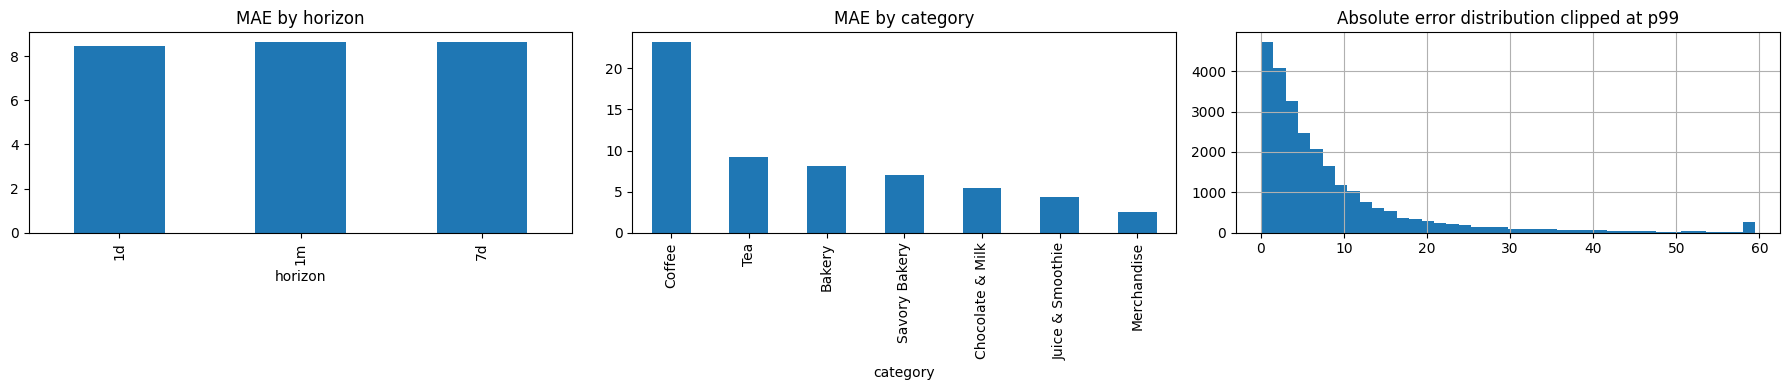

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
valid_diag.groupby("horizon")["abs_error"].mean().plot(kind="bar", ax=axes[0], title="MAE by horizon")
valid_diag.groupby("category")["abs_error"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1], title="MAE by category")
valid_diag["abs_error"].clip(upper=valid_diag["abs_error"].quantile(0.99)).hist(ax=axes[2], bins=40)
axes[2].set_title("Absolute error distribution clipped at p99")
plt.tight_layout()
plt.show()


## 25. Retrain Final Models with Full Jan-Oct Data

This cell retrains the final CatBoost models using all available training rows up to `2024-10-31` after validation is complete.

Why this matters: the validation cell trains only on data before `2024-09-01`, so using those models directly for submission leaves Sep-Oct unused. For the final submission, we keep the best iteration count from validation, then fit again on the full training period.


In [ ]:
final_models = {}

for horizon in ["1d", "7d", "1m"]:
    print("\n" + "=" * 80)
    print("Final training horizon:", horizon)

    df_h = train_all[train_all["horizon"] == horizon].copy()
    X_full = clean_features(df_h, feature_cols, cat_cols)
    y_full = df_h["target_units_sold"].astype("float32")
    full_weight = df_h["sample_weight"].values if USE_STOCKOUT_WEIGHTS else None

    cat_feature_indices = [X_full.columns.get_loc(c) for c in cat_cols]
    full_pool = Pool(X_full, y_full, cat_features=cat_feature_indices, weight=full_weight)

    best_iter = models[horizon].get_best_iteration()
    final_params = MODEL_PARAMS.copy()
    final_params["iterations"] = int(best_iter + 1) if best_iter is not None and best_iter >= 0 else MODEL_PARAMS["iterations"]
    final_params["od_type"] = None
    final_params["od_wait"] = None
    final_params["verbose"] = 200

    final_model = CatBoostRegressor(**final_params)
    final_model.fit(full_pool)
    final_models[horizon] = final_model
    print(f"{horizon} final iterations: {final_params['iterations']}")



Final training horizon: 1d
0:	learn: 29.5169924	total: 47.9ms	remaining: 1m 25s
200:	learn: 9.1602096	total: 8.17s	remaining: 1m 4s
400:	learn: 8.4959202	total: 16.7s	remaining: 58.1s
600:	learn: 8.1588120	total: 25.2s	remaining: 50.1s
800:	learn: 7.9689102	total: 33.6s	remaining: 41.7s
1000:	learn: 7.8214858	total: 42.2s	remaining: 33.4s
1200:	learn: 7.7070660	total: 50.8s	remaining: 25.1s
1400:	learn: 7.6107988	total: 59.1s	remaining: 16.6s
1600:	learn: 7.5248559	total: 1m 7s	remaining: 8.15s
1793:	learn: 7.4458950	total: 1m 15s	remaining: 0us
1d final iterations: 1794

Final training horizon: 7d
0:	learn: 29.7104645	total: 45ms	remaining: 1m 52s
200:	learn: 9.3135181	total: 8.14s	remaining: 1m 33s
400:	learn: 8.5610360	total: 16.6s	remaining: 1m 26s
600:	learn: 8.2187119	total: 25s	remaining: 1m 18s
800:	learn: 8.0027682	total: 33.1s	remaining: 1m 10s
1000:	learn: 7.8376735	total: 41.7s	remaining: 1m 2s
1200:	learn: 7.6990945	total: 50.1s	remaining: 54.2s
1400:	learn: 7.5928286	tot

## 26. Predict Test และสร้าง Submission

Cell นี้ predict ตาม horizon แล้วรวมกลับเป็นไฟล์ submission schema เดิม


In [ ]:
submission = sample[["id"]].copy()
submission["units_sold_predicted"] = np.nan

for horizon in ["1d", "7d", "1m"]:
    idx = test_all["horizon"] == horizon
    X_test = clean_features(test_all.loc[idx], feature_cols, cat_cols)
    model_for_submit = final_models[horizon] if "final_models" in globals() else models[horizon]
    pred = np.maximum(model_for_submit.predict(X_test), 0)
    submission.loc[idx.values, "units_sold_predicted"] = pred
    print(horizon, "rows:", idx.sum(), "pred mean:", float(np.mean(pred)))

display(submission.head())
display(submission["units_sold_predicted"].describe())


1d rows: 8540 pred mean: 46.062517874639866
7d rows: 8540 pred mean: 46.15559168893495
1m rows: 8540 pred mean: 46.944284622739616


,id,units_sold_predicted
0,1_Bakery_2024-11-01_1d,32.688460
1,1_Bakery_2024-11-01_1m,31.502176
2,1_Bakery_2024-11-01_7d,35.193064
3,1_Bakery_2024-11-02_1d,15.580711
4,1_Bakery_2024-11-02_1m,14.583881


,units_sold_predicted
count,25620.000000
mean,46.387465
std,57.670735
min,0.950342
25%,12.848740
50%,26.044277
75%,50.697389
max,742.098449


## 27. Submission Sanity Checks

Cell นี้เช็กว่าไฟล์ตรง schema: 2 columns, row count เท่าตัวอย่าง, id ตรง, ไม่มีค่าติดลบ/ค่าว่าง


In [ ]:
assert list(submission.columns) == ["id", "units_sold_predicted"]
assert len(submission) == len(sample)
assert submission["id"].equals(sample["id"])
assert submission["id"].is_unique
assert submission["units_sold_predicted"].notna().all()
assert (submission["units_sold_predicted"] >= 0).all()

submission.to_csv(OUTPUT_PATH, index=False)
print("Wrote:", OUTPUT_PATH.resolve())
print("Rows:", len(submission))


Wrote: /content/submission_catboost_high_corr.csv
Rows: 25620


## 28. Optional: Save Feature Importance

Cell นี้บันทึก feature importance ไว้ใช้ตอน pitching/technical explanation


In [ ]:
fi_all = pd.concat(feature_importances.values(), ignore_index=True)
fi_path = OUTPUT_PATH.with_name("catboost_feature_importance.csv")
fi_all.to_csv(fi_path, index=False)
print("Wrote:", fi_path.resolve())
display(fi_all.groupby("feature")["importance"].mean().sort_values(ascending=False).head(30))


Wrote: /content/catboost_feature_importance.csv


,importance
feature,
sales_lag0,9.876374
sales_roll_mean_7,9.308436
max_base_price,8.259025
sales_roll_mean_14,7.877550
category,5.960384
avg_base_price,5.548818
event_type,5.341816
sales_roll_mean_28,3.594428
neighborhood_type,3.327745
